In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import json
import os

# Config
DATASET = "MNIST"
NUM_CLASSES = 10
BATCH_SIZE = 32
EPOCHS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
print(f"Dataset: {DATASET}")

Device: cuda
Dataset: MNIST


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
test_ds = datasets.MNIST(root='./data', train=False, download=False, transform=transform)

trainloader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(trainloader)}")
print(f"Test batches: {len(testloader)}")

Train batches: 1875
Test batches: 313


In [3]:
class MLP(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

model = MLP(num_classes=NUM_CLASSES).to(DEVICE)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = nn.CrossEntropyLoss()

print(model)

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [4]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total


# Training
train_losses, train_accs = [], []
test_losses, test_accs = [], []

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, trainloader, optimizer, criterion, DEVICE)
    te_loss, te_acc = evaluate(model, testloader, criterion, DEVICE)

    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    test_losses.append(te_loss)
    test_accs.append(te_acc)

    print(f"Epoch {epoch:2d} | Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f} | Test Loss: {te_loss:.4f} | Test Acc: {te_acc:.4f}")

Epoch  1 | Train Loss: 0.0079 | Train Acc: 0.9220 | Test Loss: 0.0033 | Test Acc: 0.9673
Epoch  2 | Train Loss: 0.0031 | Train Acc: 0.9698 | Test Loss: 0.0029 | Test Acc: 0.9714
Epoch  3 | Train Loss: 0.0022 | Train Acc: 0.9784 | Test Loss: 0.0025 | Test Acc: 0.9751
Epoch  4 | Train Loss: 0.0016 | Train Acc: 0.9833 | Test Loss: 0.0038 | Test Acc: 0.9658
Epoch  5 | Train Loss: 0.0012 | Train Acc: 0.9875 | Test Loss: 0.0026 | Test Acc: 0.9754
Epoch  6 | Train Loss: 0.0010 | Train Acc: 0.9895 | Test Loss: 0.0027 | Test Acc: 0.9763
Epoch  7 | Train Loss: 0.0009 | Train Acc: 0.9905 | Test Loss: 0.0030 | Test Acc: 0.9737
Epoch  8 | Train Loss: 0.0007 | Train Acc: 0.9921 | Test Loss: 0.0033 | Test Acc: 0.9738
Epoch  9 | Train Loss: 0.0006 | Train Acc: 0.9940 | Test Loss: 0.0028 | Test Acc: 0.9777
Epoch 10 | Train Loss: 0.0004 | Train Acc: 0.9956 | Test Loss: 0.0031 | Test Acc: 0.9782
Epoch 11 | Train Loss: 0.0004 | Train Acc: 0.9961 | Test Loss: 0.0030 | Test Acc: 0.9787
Epoch 12 | Train Loss

In [5]:
os.makedirs('./evaluation', exist_ok=True)

results = {
    "train_losses": train_losses,
    "train_accs": train_accs,
    "test_losses": test_losses,
    "test_accs": test_accs,
    "final_test_accuracy": test_accs[-1],
    "final_test_loss": test_losses[-1]
}

filename = f"./evaluation/{DATASET.lower()}_mlp_centralized_results.json"
with open(filename, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {filename}")
print(f"Final Test Accuracy: {test_accs[-1]*100:.2f}%")

Results saved to ./evaluation/mnist_mlp_centralized_results.json
Final Test Accuracy: 98.15%


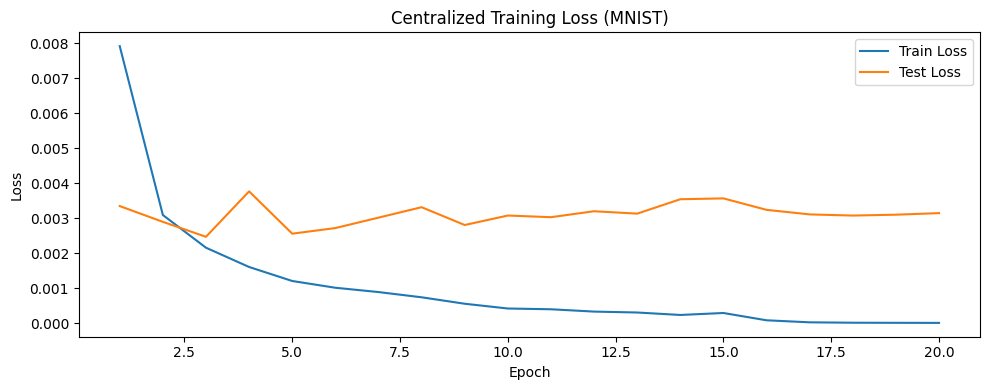

In [6]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Centralized Training Loss ({DATASET})')
plt.legend()
plt.tight_layout()
plt.savefig(f'./evaluation/{DATASET.lower()}_centralized_loss.png')
plt.show()

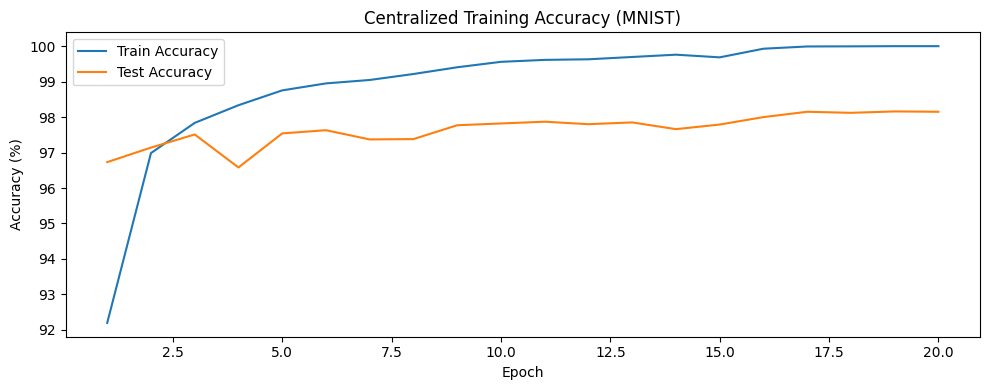

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(epochs, [a*100 for a in train_accs], label='Train Accuracy')
plt.plot(epochs, [a*100 for a in test_accs], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title(f'Centralized Training Accuracy ({DATASET})')
plt.legend()
plt.tight_layout()
plt.savefig(f'./evaluation/{DATASET.lower()}_centralized_accuracy.png')
plt.show()